In [3]:
# import packages
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
from eofs.xarray import Eof
from scipy import signal

In [4]:
def help_adding_year(yr):
    """
    Update year string by adding one and return string.
    Args:
        yr (str): year
    """
    assert len(yr) == 4, 'year string is not correct length!'
    newyr = int(yr) + 1
    newyr = str(newyr)
    newyr = newyr.zfill(4)
    return newyr


def convert_mo_str(mo):
    """
    Convert integer month to two-digit month string.
    Args:
        mo (int): month
    """
    assert type(mo) is int, 'not an integer'
    return str(mo).zfill(2)


def help_updating_time(mo, yr):
    """
    Updating the month and year in cftime due to february start in cesm.
    Year and month (if december) are fixed.
    Args:
        mo (str): xarray filename
        yr (str): xarray filename
    """
    newmo = int(mo) + 1
    if newmo == 13:
        yr = help_adding_year(yr)
        newmo = 1
    assert newmo <= 12, 'month is greater than 12, there is an error!'
    newmo = convert_mo_str(newmo)
    return newmo, yr


def fixtime(ds):
    """
    Open file and add time coordinate.
    Args:
        ds (xarray dataset)
    """
    # start date range preprocessing
    mo0 = ds.encoding['source'].split('/')[-1].split('.')[-2][4:6]
    yr0 = ds.encoding['source'].split('/')[-1].split('.')[-2][:4]
    nm0, ny0 = help_updating_time(mo0, yr0)
    # end date range preprocessing
    yr1 = ds.encoding['source'].split('/')[-1].split('.')[-2][-6:-2]
    mo1 = ds.encoding['source'].split('/')[-1].split('.')[-2][-2:]
    nm1, ny1 = help_updating_time(mo1, yr1)
    # create datetime array in cftime
    newtime = xr.cftime_range(
        start=ny0+'-'+nm0+'-01',
        end=ny1+'-'+nm1+'-01',
        freq='MS',
        calendar='noleap'
    )
    ds = ds.assign_coords(time=newtime)
    return ds

In [5]:
def get_ClusterClient():
    import dask
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client
    cluster = PBSCluster(
        cores=1,
        memory='10GB',
        processes=1,
        queue='casper',
        resource_spec='select=1:ncpus=1:mem=10GB',
        account='UMCP0030',
        walltime='02:00:00')
        #interface='ib0',)

    dask.config.set({
        'distributed.dashboard.link':
        'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
    })
    client = Client(cluster)
    return cluster, client

In [6]:
cluster, client = get_ClusterClient()
#cluster.scale(20) 
cluster.adapt(minimum=0, maximum=20)

In [7]:
cluster

Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/ewisinski/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.116:39827,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/ewisinski/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [28]:
# Close out Dask Cluster and release workers:
# NOTE:  only run this cell to terminate Dask Cluster!
cluster.close()
client.close()

In [8]:
# combine piControl 1 year runs (50 files) into a single 500 year file
# do for various monthly ocean and atmosphere variables
ds_temp_ocn = xr.open_mfdataset(
    '/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/v2.FV1.piControl/ocn/proc/tseries/month_1/v2.FV1.piControl.mpaso.hist.am.timeMonthly_avg_activeTracers_temperature.*.nc'
)

/glade/derecho/scratch/ewisinski/tmp/ipykernel_54035/3209405961.py:3: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_temp_ocn = xr.open_mfdataset(


In [9]:
# print variables to check dimensions
ds_temp_ocn

<xarray.Dataset> Size: 96GB
Dimensions:                                    (time: 6000, lat: 180, nbnd: 2,
                                                lon: 360, nVertLevels: 60)
Coordinates:
  * time                                       (time) object 48kB 0001-02-01 ...
  * lat                                        (lat) float64 1kB -89.5 ... 89.5
  * lon                                        (lon) float64 3kB 0.5 ... 359.5
Dimensions without coordinates: nbnd, nVertLevels
Data variables:
    lat_bnds                                   (time, lat, nbnd) float64 17MB dask.array<chunksize=(120, 180, 2), meta=np.ndarray>
    lon_bnds                                   (time, lon, nbnd) float64 35MB dask.array<chunksize=(120, 360, 2), meta=np.ndarray>
    gw                                         (time, lat) float64 9MB dask.array<chunksize=(120, 180), meta=np.ndarray>
    area                                       (time, lat, lon) float64 3GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    timeMonthly_avg_activeTracers_temperature  (time, nVertLevels, lat, lon) float32 93GB dask.array<chunksize=(120, 60, 180, 360), meta=np.ndarray>
    time_bnds                                  (time, nbnd) object 96kB dask.array<chunksize=(120, 2), meta=np.ndarray>
Attributes: (12/756)
    title:                                                        MPAS-Ocean ...
    source:                                                       CAM
    source_id:                                                    96c3ee8f6d
    product:                                                      model-output
    realm:                                                        ocean
    case:                                                         b.e21.B1850...
    ...                                                           ...
    host:                                                         cheyenne4
    initial_file:                                                 b.e20.B1850...
    topography_file:                                              /glade/p/ce...
    model_doi_url:                                                https://doi...
    time_period_freq:                                             month_1
    history_of_appended_files:                                    Fri Apr 28 ...

In [10]:
ds_temp_ocn = ds_temp_ocn.assign_coords(time=ds_temp_ocn['time'] - 
                                        xr.coding.cftime_offsets.MonthBegin(1))

In [11]:
ds_temp_ocn

<xarray.Dataset> Size: 96GB
Dimensions:                                    (time: 6000, lat: 180, nbnd: 2,
                                                lon: 360, nVertLevels: 60)
Coordinates:
  * time                                       (time) object 48kB 0001-01-01 ...
  * lat                                        (lat) float64 1kB -89.5 ... 89.5
  * lon                                        (lon) float64 3kB 0.5 ... 359.5
Dimensions without coordinates: nbnd, nVertLevels
Data variables:
    lat_bnds                                   (time, lat, nbnd) float64 17MB dask.array<chunksize=(120, 180, 2), meta=np.ndarray>
    lon_bnds                                   (time, lon, nbnd) float64 35MB dask.array<chunksize=(120, 360, 2), meta=np.ndarray>
    gw                                         (time, lat) float64 9MB dask.array<chunksize=(120, 180), meta=np.ndarray>
    area                                       (time, lat, lon) float64 3GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    timeMonthly_avg_activeTracers_temperature  (time, nVertLevels, lat, lon) float32 93GB dask.array<chunksize=(120, 60, 180, 360), meta=np.ndarray>
    time_bnds                                  (time, nbnd) object 96kB dask.array<chunksize=(120, 2), meta=np.ndarray>
Attributes: (12/756)
    title:                                                        MPAS-Ocean ...
    source:                                                       CAM
    source_id:                                                    96c3ee8f6d
    product:                                                      model-output
    realm:                                                        ocean
    case:                                                         b.e21.B1850...
    ...                                                           ...
    host:                                                         cheyenne4
    initial_file:                                                 b.e20.B1850...
    topography_file:                                              /glade/p/ce...
    model_doi_url:                                                https://doi...
    time_period_freq:                                             month_1
    history_of_appended_files:                                    Fri Apr 28 ...

In [12]:
print(ds_temp_ocn['timeMonthly_avg_activeTracers_temperature'].shape) 

(6000, 60, 180, 360)


In [13]:
temp = ds_temp_ocn['timeMonthly_avg_activeTracers_temperature']

In [14]:
temp_pacific = temp.sel(lat=slice(20, 70), lon=slice(110, 260))

In [15]:
sst_pacific = temp_pacific[:, 0]

In [16]:
sst_pacific

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000,
                                                               lat: 50, lon: 150)> Size: 180MB
dask.array<getitem, shape=(6000, 50, 150), dtype=float32, chunksize=(120, 50, 150), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
  * lat      (lat) float64 400B 20.5 21.5 22.5 23.5 24.5 ... 66.5 67.5 68.5 69.5
  * lon      (lon) float64 1kB 110.5 111.5 112.5 113.5 ... 257.5 258.5 259.5
Attributes:
    long_name:      potential temperature
    units:          degrees Celsius
    cell_measures:  area: area
    cell_methods:   time: mean

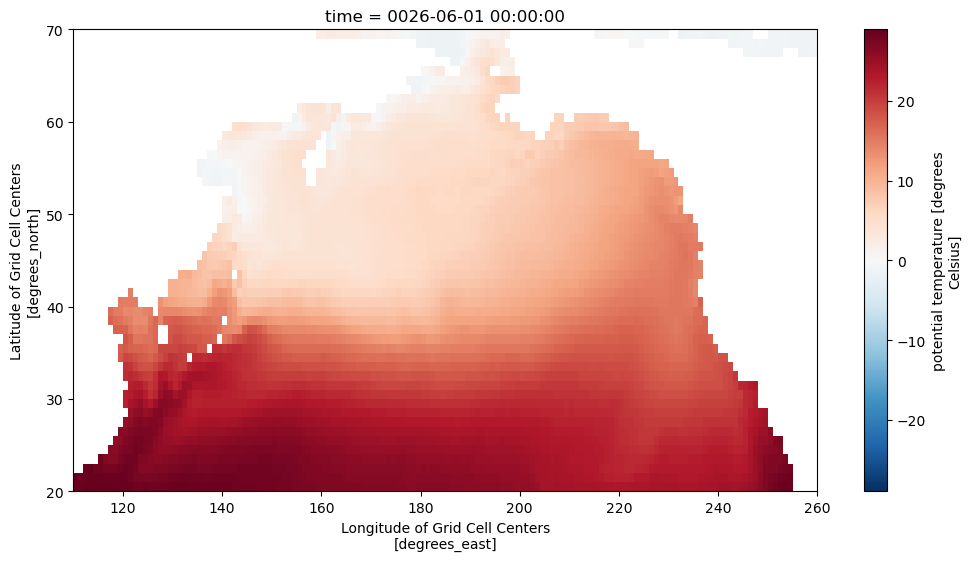

In [17]:
sst_pacific[305].plot.pcolormesh(figsize=(12,6))

In [18]:
# remove seasonal cycle
sst_clim = sst_pacific.groupby('time.month').mean('time')
sst_anom = sst_pacific.groupby('time.month') - sst_clim

In [19]:
# remove long term trend (recommended even in picontrol)

sst_anom_loaded = sst_anom.load()
nan_mask = np.isnan(sst_anom_loaded).any(dim='time')

# detrend along axis=0 (time) directly - much faster
vals = sst_anom_loaded.fillna(0.0).values
detrended_vals = signal.detrend(vals, axis=0)

# Wrap back into DataArray and restore NaNs
sst_anom_detrended = xr.DataArray(
    detrended_vals,
    coords=sst_anom_loaded.coords,
    dims=sst_anom_loaded.dims
).where(~nan_mask)

# Restore NaNs
sst_anom_detrended = sst_anom_detrended.where(~nan_mask)

In [20]:
# area weighted EOF
weights = np.cos(np.deg2rad(sst_anom.lat))
sst_weighted = sst_anom_detrended * np.sqrt(weights)

In [21]:
# run the EOF

solver = Eof(sst_weighted)
eof1 = solver.eofsAsCorrelation(neofs=1)
pdo_index = solver.pcs(npcs=1, pcscaling=1).squeeze()

In [22]:
# do some sanity checks
# the pdo positive phase has cool SST anomalies in the central north pacific and warm anomalies along the coast
# if the eof is flipped, just multiply by neg 1
eof1 *= -1
pdo_index *= -1

In [23]:
pdo_index[:20].values

array([-0.57074441,  0.14520582,  0.01989004,  0.28544161,  0.22837063,
        0.38801161,  0.7299327 ,  0.9602382 ,  0.82131666,  0.83109235,
        0.80523288,  0.52586669,  0.94650468,  0.88462978,  1.12625057,
        1.03251222,  0.65588886,  0.34926076, -0.16295675,  0.29975504])

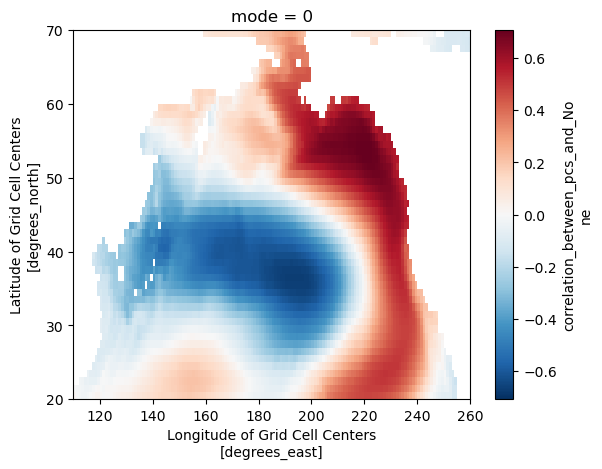

In [24]:
# Plot the EOF pattern to verify
eof1.plot()

In [25]:
pdo_index.to_netcdf('pdo.nc')

In [26]:
print(solver.varianceFraction(neigs=1).values)

[0.17342926]


[0.17342926 0.12332855 0.07731917]


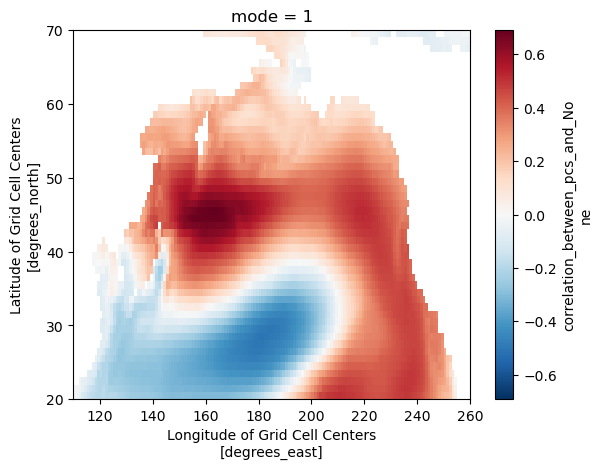

In [27]:
# Check variance fractions for first 3 modes
print(solver.varianceFraction(neigs=3).values)

# Plot EOF2
eof2 = solver.eofsAsCorrelation(neofs=2)
eof2[1].plot()